# Two-step outlier analysis using normalizing flows

In [1]:
import json
import pathlib

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import corner

import jax
jax.config.update('jax_enable_x64', True)
import discovery as ds
# import the newly implemented outlier module
from discovery.models.nanograv_single_pulsar_outlier import  *
from discovery.models.fourierpta import * 
from discovery.models.flowfourierpta import *

import numpyro.distributions as dist
import numpyro.infer as infer
from numpyro.infer import init_to_value
import numpyro.handlers as handlers


c:\Users\tresn\miniconda3\envs\discovery\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
plt.style.use("matplotlib.mplstyle")

In [3]:
# read in psr file with outlier contamination
psr = ds.Pulsar.read_feather(r"../data/J1643-1224_with_outliers.feather")

In [4]:
# loading in psrs
npsr = 1
DATA = pathlib.Path(ds.__path__[0] + '/../../data/')
allpsrs = sorted( [ds.Pulsar.read_feather(psrfile) for psrfile in list(DATA.glob("*-[JB]*.feather"))],
    key=lambda psr: len(psr.toas), reverse = True)


In [5]:
# extracting the noisedict since we will do the outlier analysis
# using fixed WN
psr_name = "J1643-1224"
psr_idx = [p.name for p in allpsrs].index(psr_name)
psr_tmp = allpsrs[psr_idx]
noisedict = psr_tmp.noisedict
psr.noisedict = noisedict

In [6]:
newdict = {'(.*_)?red_noise_coefficients\\(([0-9]*)\\)': [-100, 100]}

In [7]:
rn_components = 30
gw_components = 14
powerlaw = ds.powerlaw
ecorr = True 
tnequad = False

### Set your regularizer

In [8]:
eta0_regularizer = [{"log10_A": -12.0, "gamma": 3.0} ] # set 

### Create your outlier likelihood

In [9]:
# create outlier likelihood using a fixed psd which (conditioned on our regularizer eta_0)
psrl = make_outlier_likelihood(psr, psd = ds.partial(ds.powerlaw, **eta0_regularizer[0]))

In [10]:
Tspan = ds.getspan(psr)
f, df, _ = signals.fourierbasis(psr, rn_components, T=Tspan)
phi0_inv, logdet_phi0 = phi_single_pulsar(eta0_regularizer[0], f, df, ds.powerlaw)

In [11]:
psrl.logL.params

['J1643-1224_3GHz_YUPPI_efac',
 'J1643-1224_3GHz_YUPPI_log10_ecorr',
 'J1643-1224_3GHz_YUPPI_log10_t2equad',
 'J1643-1224_Rcvr1_2_GASP_efac',
 'J1643-1224_Rcvr1_2_GASP_log10_ecorr',
 'J1643-1224_Rcvr1_2_GASP_log10_t2equad',
 'J1643-1224_Rcvr1_2_GUPPI_efac',
 'J1643-1224_Rcvr1_2_GUPPI_log10_ecorr',
 'J1643-1224_Rcvr1_2_GUPPI_log10_t2equad',
 'J1643-1224_Rcvr_800_GASP_efac',
 'J1643-1224_Rcvr_800_GASP_log10_ecorr',
 'J1643-1224_Rcvr_800_GASP_log10_t2equad',
 'J1643-1224_Rcvr_800_GUPPI_efac',
 'J1643-1224_Rcvr_800_GUPPI_log10_ecorr',
 'J1643-1224_Rcvr_800_GUPPI_log10_t2equad',
 'J1643-1224_alpha_scaling(26684)']

### Building the pulsar flow object

In [12]:
# create the flow pulsar object with the psrl set by outlier model 
flow_psr = FlowPulsarFourierSummary(psr.name, 
                                    psl=psrl,
                                    eta0 =eta0_regularizer[0],
                                    phi0_inv = phi0_inv, 
                                    logdet_phi0 = logdet_phi0,
                                    ahat0r = None, # set to None for now, extract from above conditional
                                    L0r = None) # same as above

# However, the psrl object that we supply is important for the rn_slice property below

### Computing conditional quantities needed for latent space transformation

We want to fit a normalizing flow $q_{\boldsymbol{\psi}}(\mathbf a \mid \boldsymbol{\delta t}, \boldsymbol{\eta}_0)$, but we want to perform the fit in a latent space $\mathbf y$ where
$$
\begin{equation}
    \mathbf y = \mathbf L_{0, \alpha=1}^{-1}(\mathbf a - \mathbf{\hat a}_{0,\alpha=1}).
\end{equation}
$$

The normalizing flow in the Fourier coefficient space and the latent space is then related by a constant determinant factor
$$
\begin{equation}
q_{\boldsymbol{\psi}}(\mathbf a \mid \boldsymbol{\delta t}, \boldsymbol{\eta}_0) = f_{\boldsymbol{\psi}}(\mathbf y \mid \boldsymbol{\delta t}, \boldsymbol{\eta}_0) \vert \det \mathbf L_{0,\alpha=1}^{-1} \vert
\end{equation}
$$

In [13]:
nd = psr.noisedict
nd_alpha = nd.copy()
nd_alpha.update({"J1643-1224_alpha_scaling(26684)": jnp.ones((26684,))})

ahat_alpha, cf_inv_alpha = psrl.conditional(nd_alpha)

In [14]:
slice = flow_psr.rn_slice
ahat0r = ahat_alpha[slice]
cf_inv0r = cf_inv_alpha[0][slice, slice]

In [15]:
flow_psr.is_ready_for_step2

Pulsar J1643-1224 is missing the following quantities: ['ahat0r', 'L0r', 'bf', 'TtNTf', 'flow', 'ahat_f', 'Sigma_f', 'L_f']


False

In [16]:
flow_psr.ahat0r = ahat0r
flow_psr.L0r = jnp.linalg.cholesky(jnp.linalg.inv(cf_inv0r @ cf_inv0r.T))

We aer still left with populating the pulsar object with the fields above. As long as a trained flow is supplied, the remaining quantities can be computed. To train the flow however, we need to generate samples on the Fourier coefficients. We perform the coefficient sampling jointly with the outlier sampling.

### Sampling with fixed WN

Our hierarchical model is given by

$$
\begin{aligned}
p(\boldsymbol{\delta t} \mid \mathbf{b}, \boldsymbol{\theta}_\mathrm{WN}, \mathbf{z}, \boldsymbol{\alpha}) &= \mathcal{N}(\boldsymbol{\delta t} \mid \mathbf{T}\mathbf{b}, \mathbf{N}_\alpha(\boldsymbol{\theta}_\mathrm{WN})) \\
p(\mathbf{b} \mid \boldsymbol{\eta}) &= \mathcal{N}(\mathbf{b} \mid \mathbf{0}, \boldsymbol{\Phi}(\boldsymbol{\eta})) \\
p(z_i \mid \lambda) &= \mathrm{Bernoulli}(\lambda) \\
p(\lambda) &= \mathrm{Beta}(km, k(1-m)) \\
p(\alpha_i) &= \mathrm{InvGamma}(\nu/2, \nu/2) \\
p(\nu) &= \mathcal{U}([\nu_\mathrm{low}, \nu_\mathrm{high}])
\end{aligned}
$$
wiht  $\mathbf N_\alpha = \mathrm{diag}(\alpha_i^{z_i}) \mathbf N$ and where the white noise $\boldsymbol \theta_\mathrm{WN}$ is held fixed and $\boldsymbol \eta$ contains our red noise and ECORR hyperparameters with ECORR treated as GP process

Since the first step of the two-step procedure involves generating samples at a fixed $\boldsymbol \eta_0$, the HMC-within-Gibbs scheme from which we use to generate our samples below, takes the form (under fixed white noise)
$$
\begin{aligned}
\Pi_1(\nu) &\sim \mathrm{HMC}\\
\Pi_2(\mathbf{b}) &= \mathcal{N}(\mathbf{b} \mid \hat{\mathbf{b}}_\alpha, \boldsymbol{\Sigma}_\alpha)\\
\Pi_3(\lambda) &= \mathrm{Beta}\left(km + z_\mathrm{tot},\, k(1-m) + N_\mathrm{TOA} - z_\mathrm{tot} \right) \\
\Pi_4(z_i) &= \mathrm{Bernoulli}\left(\frac{\lambda \,\mathcal{N}(r_i \mid \mathbf{0}, (\mathbf{N}_\alpha)_{ii})}{\lambda\, \mathcal{N}(r_i \mid \mathbf{0}, (\mathbf{N}_\alpha)_{ii}) + (1-\lambda)\, \mathcal{N}(r_i \mid \mathbf{0}, (\mathbf{N})_{ii})}\right)\\
\Pi_5(\alpha_i) &= \mathrm{InvGamma}\left(\frac{1}{2}(\nu + z_i),\, \frac{1}{2}\left(\nu + z_i \frac{r_i^2}{(\mathbf{N})_{ii}}\right)\right)
\end{aligned}
$$
which reduces to a fully Gibbsian scheme whenever $\nu$ is held fixed. We additionally introduces the quantities

$$
\begin{aligned}
\hat{\mathbf{b}}_\alpha &= \bSigma_\alpha \mathbf{T}^\top \mathbf{N}_\alpha^{-1} \boldsymbol{\delta t}, \quad \bSigma_\alpha^{-1} = \mathbf{T}^\top \mathbf{N}_\alpha^{-1} \mathbf{T} + \boldsymbol{\Phi}^{-1}, \quad z_\mathrm{tot} = \sum_{i=1}^{N_\mathrm{TOA}} z_i, \quad r_i = [\boldsymbol{\delta t} - \mathbf{T}\mathbf{b}]_i
\end{aligned}
$$


In [17]:
psrl.N.N_var.getN(nd_alpha) # this is now a diagonal noise matrix since ECORR treated as GP process

Array([1.18376975e-11, 1.08567111e-11, 1.09673383e-11, ...,
       5.03400866e-11, 3.19999737e-10, 2.37988732e-10], dtype=float64)

In [18]:
from discovery.models.nanograv_single_pulsar_outlier import _partition_params, _lookup_prior, priordict_outlier_default

partition = _partition_params(psrl)
priordict = priordict_outlier_default

efac_range = _lookup_prior(partition["efac"][0],  priordict)
equad_range = _lookup_prior(partition["equad"][0], priordict)
ecorr_range = _lookup_prior(partition["ecorr"][0], priordict) if partition["ecorr"] else None
nu_range = priordict["nu"]


In [19]:
model = make_outlier_model(psrl)
gibbs_fn = make_outlier_gibbs_fn(psrl)

wn_fixed = psr.noisedict

n_coeff = 2*rn_components
N = psrl.y.size

# fix the wn sites using .condition from numpyro
fixed_wn_sites = {"efacs":  jnp.array([wn_fixed[k] for k in partition["efac"]]),
    "equads": jnp.array([wn_fixed[k] for k in partition["equad"]]),
    "ecorrs": jnp.array([wn_fixed[k] for k in partition["ecorr"]]),}
conditioned_model = handlers.condition(model, data=fixed_wn_sites)

init_params = { "nu": jnp.array(4.0),
    "theta": jnp.array(0.1),
    "z_i": jnp.zeros(N, dtype=jnp.int32),
    "q": jnp.ones(N) * 0.5,
    "alpha_i": jnp.ones(N),
    "coeffs": jnp.zeros(n_coeff)} # coeffs here represents will represent our Fourier domain coefficients (not whitened)

raw_gibbs = gibbs_fn

def hmc_fixed_gibbs_fn(rng_key, gibbs_sites, hmc_sites):
    hmc_sites_fixed = dict(hmc_sites)
    hmc_sites_fixed["efacs"]  = fixed_wn_sites["efacs"]
    hmc_sites_fixed["equads"] = fixed_wn_sites["equads"]
    hmc_sites_fixed["ecorrs"] = fixed_wn_sites["ecorrs"]
    result = raw_gibbs(rng_key, gibbs_sites, hmc_sites_fixed)
    return result

nuts = infer.NUTS(conditioned_model, init_strategy=init_to_value(values=init_params))
kernel = infer.HMCGibbs(nuts, gibbs_fn=jax.jit(hmc_fixed_gibbs_fn),
    gibbs_sites=["theta", "z_i", "alpha_i", "coeffs", "q"])

sampler = infer.MCMC(kernel, num_warmup=128, num_samples=1024, progress_bar=True)
sampler.run(jax.random.key(0))
samples = sampler.get_samples()

coeffs_samples = samples["coeffs"] 
a_samples = np.array(coeffs_samples)

sample: 100%|██████████| 1152/1152 [08:11<00:00,  2.34it/s, 1 steps of size 8.81e-01. acc. prob=0.92]


In [20]:
samples.keys()

dict_keys(['alpha_i', 'coeffs', 'loglike', 'nu', 'params', 'q', 'theta', 'z_i'])

In [21]:
flow_psr.samples = samples

In [22]:
flow_psr.samples.keys()

dict_keys(['alpha_i', 'coeffs', 'loglike', 'nu', 'params', 'q', 'theta', 'z_i'])

In [23]:
# append Fourier coeff samples to flow_psr object which is later called on when the flow is fit
flow_psr.samples['a'] = flow_psr.samples['coeffs'][:, slice] # extracts the RN component ONLY 

In [24]:
flow_psr.samples.keys()

dict_keys(['alpha_i', 'coeffs', 'loglike', 'nu', 'params', 'q', 'theta', 'z_i', 'a'])

In [25]:
flow_psr.samples['a']

Array([[-5.75596950e-05,  1.00141513e-05,  4.23145526e-06, ...,
         2.09782313e-07,  5.83209884e-07,  1.41822993e-07],
       [-8.07514304e-06,  3.29259368e-06,  9.86909168e-07, ...,
         1.42335456e-07,  2.80792885e-07,  1.13478440e-07],
       [ 2.54001441e-05, -1.64643916e-06, -1.18589675e-06, ...,
         2.49674634e-07,  3.39027740e-07,  3.55814453e-08],
       ...,
       [-2.24172449e-05,  5.05441893e-06,  1.56992892e-06, ...,
         3.93966266e-08,  2.49944053e-07,  1.15157652e-07],
       [-4.17969167e-06,  3.72145242e-06,  9.80282096e-07, ...,
         1.77621009e-07,  2.65417437e-07,  1.01222139e-07],
       [ 5.77182977e-06,  9.15871999e-07, -2.82021745e-07, ...,
         2.52108008e-07,  2.79721503e-07,  8.29134146e-09]],      dtype=float64)

In [26]:
a_samples = flow_psr.samples['a']

In [27]:
# populates the remaining flow fields from the samples using MLE with the given MAF architecture
compute_flow_summaries([flow_psr], 0, 
                       n_flow_samples=int(1e6), 
                       learning_rate = 5e-2,
                       batch_size = 1024,
                       max_epochs = 5000,
                       flow_architecture=affine_flow_architecture) # defaults to the MAF architecture

[1/1]: Running flow step for pulsar J1643-1224


 22%|██▏       | 1103/5000 [00:07<00:27, 140.87it/s, train=84, val=86.5 (Max patience reached)]


Finished flow-fit to pulsar J1643-1224.


In [28]:
flow_psr.is_ready_for_step2

True

In [29]:
y_flow_samples = flow_psr.flow.sample(jax.random.key(0), (10000, ))

In [30]:
a_flow_samples = flow_psr.ahat0r[None, :] + y_flow_samples @ flow_psr.L0r.T

### Sampled a's vs flow a's

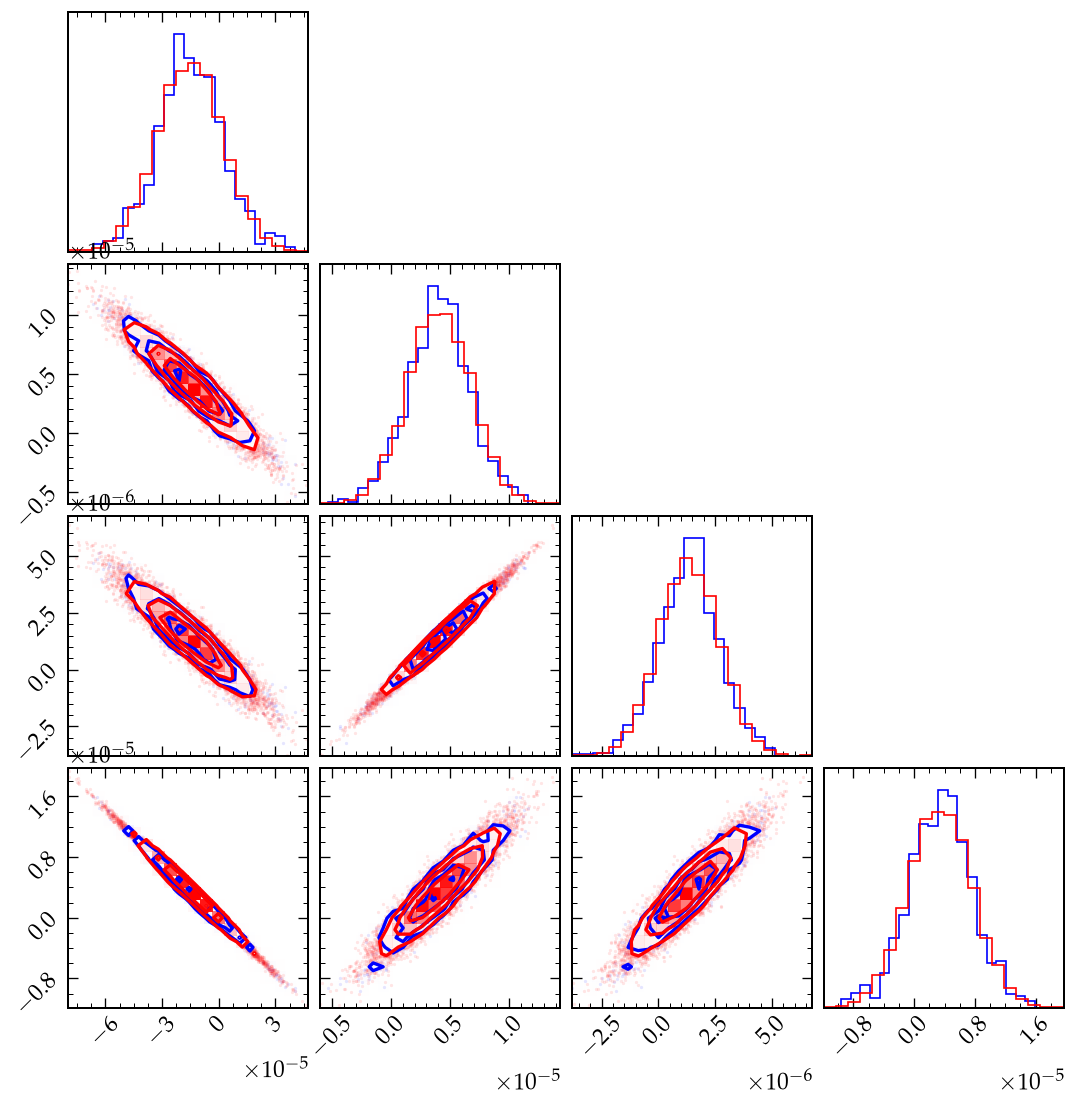

In [31]:
#visual inspection of sampled a's vs flow-constructed a's
fig = corner.corner(np.array(a_samples)[:, :4], 
                    color = 'blue', 
                    hist_kwargs = {'density':True})

# flow-constructed a's
corner.corner(np.array(a_flow_samples)[:, :4], 
              color = 'red', 
              hist_kwargs = {'density':True}, fig = fig)
plt.show()

201 of 26684 TOAs flagged as outliers


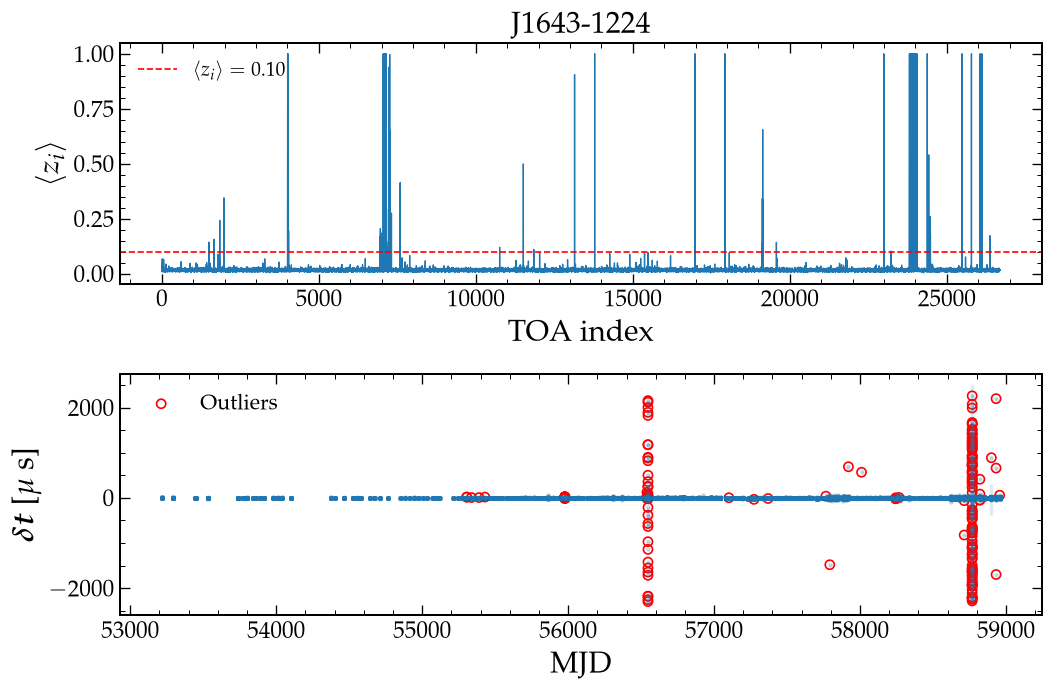

In [32]:
mask = np.mean(np.asarray(samples["z_i"]), axis=0) > 0.1
z_mean = np.mean(np.asarray(samples['z_i']), axis=0)
print(f'{mask.sum()} of {mask.size} TOAs flagged as outliers')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6))

ax1.plot(z_mean, lw=0.8)
ax1.axhline(0.1, c='r', ls='--', lw=1, label=r'$\langle z_i \rangle =0.10$')
ax1.set_xlabel('TOA index')
ax1.set_ylabel(r'$\langle z_i \rangle$')
ax1.set_title(f'{psr.name}')
ax1.legend(loc = 'upper left', fontsize = 11.8)

ax2.errorbar(psr.toas / 86400, psr.residuals/1e-6, yerr=psr.toaerrs/1e-6,
             alpha=0.15, fmt='o', markersize=2)
ax2.scatter(psr.toas[mask] / 86400, psr.residuals[mask]/1e-6,
            facecolor='none', edgecolor='r', s=30, label='Outliers')
ax2.set_xlabel('MJD')
ax2.set_ylabel(r'$\boldsymbol{\delta t}$ [$\mu$ s]')
ax2.legend()

plt.tight_layout()
plt.show()

In [33]:
samples = run_step2_SPNA_flow_corrected([flow_psr],[psr], ds.partial(phi_SPNA, powerlaw= ds.powerlaw), priordict_standard,
                    n_warmup=1024, n_samples=4096)

[1/1] Running step 2 SPNA flow-corrected for J1643-1224


sample: 100%|██████████| 5120/5120 [00:13<00:00, 368.37it/s, 7 steps of size 4.66e-01. acc. prob=0.87] 


In [34]:
m_ds = ds.ArrayLikelihood([ds.PulsarLikelihood([psr.residuals,
                            ds.makegp_timing(psr, svd=True, variable = True),
                            ds.makenoise_measurement(psr, noisedict=psr.noisedict, ecorr=ecorr),
                             ds.makegp_fourier(psr, powerlaw, rn_components, name='red_noise', T=ds.getspan(psr))]) for psr in [psr]])
                          

In [35]:
def create_rn_keys(psrnames):
    rn_amp_keys = [f"{psr_name}_red_noise_log10_A" for psr_name in psrnames]
    rn_gamma_keys = [f"{psr_name}_red_noise_gamma" for psr_name in psrnames]
    return rn_amp_keys, rn_gamma_keys

rn_amp_keys, rn_gamma_keys = create_rn_keys([s.name for s in [flow_psr]])

In [ ]:
def log_prior(rho):
    log10As = jnp.array([rho[k] for k in rn_amp_keys])# + [rho[crn_log10A_key]])
    gammas  = jnp.array([rho[k] for k in rn_gamma_keys])# + [rho[crn_gamma_key]])

    ok = jnp.all((log10As >= -20) & (log10As <= -11)) & jnp.all((gammas >= 0) & (gammas <= 7))
    log_prior_val = jnp.where(ok, 0.0, -jnp.inf)
    return log_prior_val

def potential_ds(rho):
        lp = log_prior(rho)
        return - m_ds.logL(rho) - lp
    
kernel_ds = infer.NUTS(potential_fn=potential_ds)
sampler_ds = infer.MCMC(kernel_ds, num_warmup=1024, num_samples=4096, num_chains=1, progress_bar=True)

init_params_ds = {**{k: eta0_regularizer[i]['log10_A'] for i, k in enumerate(rn_amp_keys)},
                **{k: eta0_regularizer[i]['gamma']  for i, k in enumerate(rn_gamma_keys)}}

sampler_ds.run(jax.random.key(1), init_params=init_params_ds)

samples_ds = sampler_ds.get_samples()
sampler_ds.print_summary()



sample: 100%|██████████| 5120/5120 [00:50<00:00, 100.42it/s, 3 steps of size 6.97e-01. acc. prob=0.92] 


                                    mean       std    median      5.0%     95.0%     n_eff     r_hat
    J1643-1224_red_noise_gamma      0.74      0.32      0.74      0.19      1.24   2057.95      1.00
  J1643-1224_red_noise_log10_A    -12.16      0.05    -12.16    -12.25    -12.08   1764.56      1.00

Number of divergences: 196


In [37]:
samples = samples[psr.name]

In [41]:
import pandas as pd

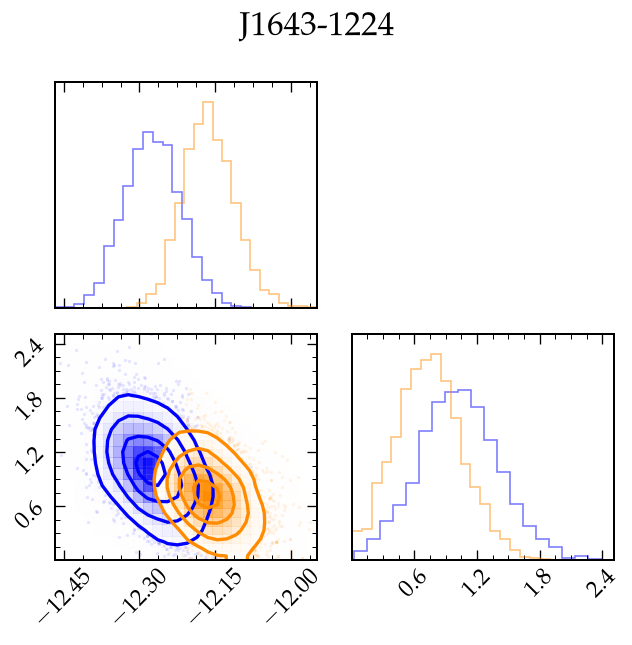

In [42]:
labels = [r"$\log_{10} A_\mathrm{IRN}$", r"$\gamma_\mathrm{IRN}$"]
labels_init = rn_amp_keys + rn_gamma_keys


irn_samples_flow = pd.DataFrame({labels[i]: samples[k] for i, k in enumerate(labels_init)})
irn_samples_ds   = pd.DataFrame({labels[i]: samples_ds[k]   for i, k in enumerate(labels_init)})

figure = corner.corner(irn_samples_flow,
                       hist_kwargs={"density": True, "alpha": 0.5, "color": "blue"},
                       color='blue',
                       show_titles=False,
                       smooth = True)

corner.corner(irn_samples_ds,
              hist_kwargs={"density": True, "alpha": 0.5, "color": "darkorange"},
              color='darkorange',
              fig=figure,
              show_titles=False,
              labelpad = 0.1,
              smooth = True)

figure.suptitle(psr.name, fontsize = 20)
plt.tight_layout()
plt.show()

### New psr object with outliers removed

In [43]:
import copy

psr_cleaned = copy.deepcopy(psr)
N_toas = mask.size

for attr, val in vars(psr).items():
    
    # if array and first entry contains old toa shape, replace with masked TOAs
    if isinstance(val, np.ndarray) and val.shape[0] == N_toas:
        setattr(psr_cleaned, attr, val[~mask])
    
    # if dict, loop over quantities inside dict and replace accordingly
    elif isinstance(val, dict):
        new_dict = {}
        for k, v in val.items():
            if isinstance(v, np.ndarray) and v.shape[0] == N_toas:
                new_dict[k] = v[~mask]
            else:
                new_dict[k] = v
        setattr(psr_cleaned, attr, new_dict)

In [44]:
# new likelihood obj. with residuals cleaned
psl_cleaned = ds.ArrayLikelihood([ds.PulsarLikelihood([
    psr_cleaned.residuals,
    ds.makegp_timing(psr_cleaned, svd=True, variable=True),
    ds.makenoise_measurement(psr_cleaned, noisedict=psr_cleaned.noisedict, ecorr=True),
    ds.makegp_fourier(psr_cleaned, powerlaw, rn_components, 
                      name='red_noise', T=ds.getspan(psr))])])

def potential_ds(rho):
    lp = log_prior(rho)
    return -psl_cleaned.logL(rho) - lp

kernel_ds = infer.NUTS(potential_fn=potential_ds)
sampler_ds_outlier_removed = infer.MCMC(kernel_ds, num_warmup=1024,
                                         num_samples=4096, progress_bar=True)
sampler_ds_outlier_removed.run(jax.random.key(1), init_params=init_params_ds)

sample: 100%|██████████| 5120/5120 [00:52<00:00, 96.73it/s, 7 steps of size 7.80e-01. acc. prob=0.91] 


In [45]:
irn_samples_ds_outliers_rem = sampler_ds_outlier_removed.get_samples()
samples_ds_outliers_rem  = {labels[i]: irn_samples_ds_outliers_rem[k]   for i, k in enumerate(labels_init)}

In [ ]:
import pandas as pd
sm = pd.read_feather(r"../data/J1643-1224_samples.feather")

dictsm = {
    rn_amp_keys[0]: sm[rn_amp_keys[0]].values,
    rn_gamma_keys[0]: sm[rn_gamma_keys[0]].values}

smsamples = np.column_stack([dictsm[rn_amp_keys[0]], dictsm[ rn_gamma_keys[0]]])



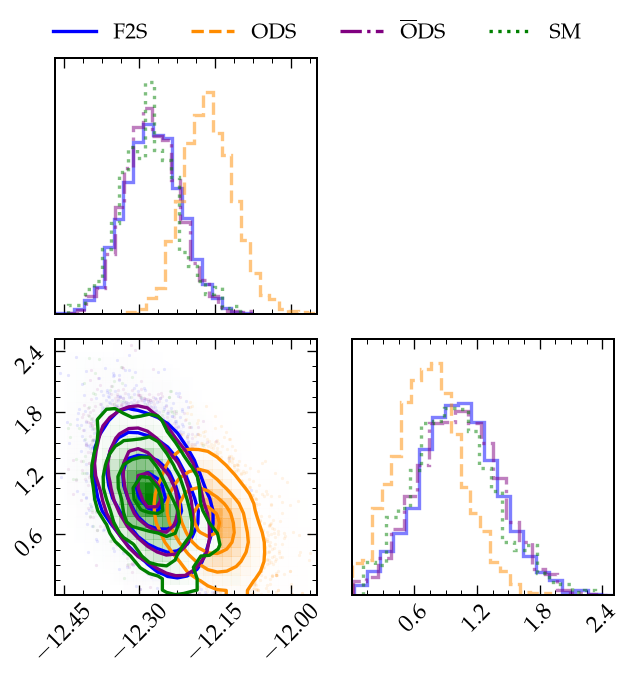

In [52]:
import matplotlib.lines as mlines

figure = corner.corner(irn_samples_flow,
                       hist_kwargs={"density": True, "alpha": 0.5, "color": "blue",
                                    "linestyle": "solid", "lw": 2},
                       color='blue',
                       show_titles=False,
                       smooth = True,
                       label = "F2S")

corner.corner(irn_samples_ds,
              hist_kwargs={"density": True, "alpha": 0.5, "color": "darkorange",
                           "linestyle": "dashed", "lw": 2},
              color='darkorange',
              fig=figure,
              show_titles=False,
              labelpad = 0.1,
              smooth = True,
              label = "O-DS")


corner.corner(pd.DataFrame(samples_ds_outliers_rem),
              hist_kwargs={"density": True, "alpha": 0.5, "color": "purple",
                           "linestyle": "dashdot", "lw": 2},
              color='purple',
              fig=figure,
              show_titles=False,
              labelpad = 0.1,
              smooth = True,
              label = r"$\mathrm{\overline{O}-DS}$")

corner.corner(pd.DataFrame(smsamples),
            hist_kwargs={"density": True, "alpha": 0.5, "color": "green",
                           "linestyle": "dotted", "lw": 2},
              color='green',
              fig=figure,
              show_titles=False,
              labelpad = 0.1,
              smooth = True,
              label = "SM")
              
legend_handles = [mlines.Line2D([], [], color='blue', linestyle='solid',    linewidth=2, label='F2S'),
    mlines.Line2D([], [], color='darkorange', linestyle='dashed',   linewidth=2, label='ODS'),
    mlines.Line2D([], [], color='purple', linestyle='dashdot',  linewidth=2, label=r'$\mathrm{\overline{O}DS}$'),
     mlines.Line2D([], [], color='green', linestyle='dotted',  linewidth=2, label='SM')]

figure.legend(handles=legend_handles, 
              loc='upper center',
              ncol = 4,
              bbox_to_anchor = (0.5, 1.05))

#figure.suptitle(psr.name, fontsize = 20, y = 1.02)
plt.tight_layout()
plt.show()

### Using moment-estimations instead of flow

Instead of fitting a normalizing flow and estimating $\mathbf {\hat a}_f, \bSigma_f$ from the flow, we can also use the law of total expectation and the law of total covariance (vvh25). Since the WN is fixed, this amounts to expectation under the sampled $\alpha$'s.

In [67]:
samples = sampler.get_samples() # accidently overwrote them
samples

{'alpha_i': Array([[0.80715407, 1.37993333, 0.53183805, ..., 0.67120528, 0.76427781,
         0.65326208],
        [0.87164894, 1.13353626, 1.37505773, ..., 1.50737764, 0.65770104,
         0.55538993],
        [1.30240912, 0.6358763 , 1.02004024, ..., 1.33415691, 0.77614906,
         1.10871196],
        ...,
        [0.75934297, 1.26060602, 1.74271306, ..., 1.28148291, 1.08464993,
         1.12072959],
        [0.89179516, 0.98864125, 1.15247953, ..., 0.79746284, 0.89305453,
         0.86945596],
        [1.29844123, 0.76343439, 0.82953473, ..., 1.2897556 , 1.16333508,
         0.96529545]], dtype=float64),
 'coeffs': Array([[-5.55578194e-03, -8.97672378e-04,  1.29997533e-04, ...,
          2.09782313e-07,  5.83209884e-07,  1.41822993e-07],
        [-6.11527323e-04, -1.88275284e-04,  5.99337593e-05, ...,
          1.42335456e-07,  2.80792885e-07,  1.13478440e-07],
        [ 2.80700673e-03,  2.40767205e-04,  3.38264149e-06, ...,
          2.49674634e-07,  3.39027740e-07,  3.55814453e-

In [75]:
N_s = len(samples['alpha_i'])  # number of Gibbs samples

alpha_i = np.array(samples['alpha_i'])  
z_i  = np.array(samples['z_i'])      

theta_samples = {}

# wn params from dict
for p in psrl.conditional.params:
    if p in samples['params'] and 'alpha_scaling' not in p:
        theta_samples[p] = np.array(samples['params'][p])  
    elif 'alpha_scaling' in p:
        theta_samples[p] = alpha_i ** z_i          
    elif p in psr.noisedict:
        theta_samples[p] = np.full(N_s, float(psr.noisedict[p]))

In [76]:
theta_param_names = [p for p in theta_samples.keys()
                     if 'red_noise' not in p and 'coefficients' not in p]
N_s = len(next(iter(theta_samples.values())))

ahat_tilde_list  = []
Sigma_tilde_list = []

for j in tqdm(range(N_s), desc=f"{psr.name}"):
    nd_j = {}
    for p in theta_param_names:
        val = np.array(theta_samples[p][j])
        nd_j[p] = float(val) if val.ndim == 0 else val

    ahat_tilde, cf_inv_tilde = psrl.conditional(nd_j)
    sigma_tilde = jsp.linalg.cho_solve(
        (cf_inv_tilde[0], True), jnp.eye(cf_inv_tilde[0].shape[0]))

    ahat_tilde_list.append(np.array(ahat_tilde[slice]))
    Sigma_tilde_list.append(np.array(sigma_tilde[slice, :][:, slice]))

ahat_tilde_array  = jnp.array(ahat_tilde_list)
Sigma_tilde_array = jnp.array(Sigma_tilde_list)

# law of total expectation
ahat0 = jnp.mean(ahat_tilde_array, axis=0)

# law of total covariance
Sigma0 = (jnp.mean(Sigma_tilde_array, axis=0)
          + jnp.cov(ahat_tilde_array.T, bias=False))

J1643-1224: 100%|██████████| 1024/1024 [04:53<00:00,  3.49it/s]


In [ ]:
L0 = jnp.linalg.cholesky(Sigma0)
b0 = jsp.linalg.cho_solve((L0, True), ahat0) # 

In [77]:
summaries_vanilla = build_fourier_psr_summaries(
    [psr], eta0_list  = eta0_regularizer,
    powerlaw = powerlaw, components = 30,
    noisedict_list = [psr.noisedict])

In [80]:
summaries_vanilla[0].__dict__

{'name': 'J1643-1224',
 'psl': <discovery.likelihood.PulsarLikelihood at 0x210a3f91410>,
 'eta0': {'log10_A': -12.0, 'gamma': 3.0},
 'phi0_inv': Array([[4.81637590e+08, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 4.81637590e+08, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 3.85310072e+09, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         1.17466592e+13, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 1.30042149e+13, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 1.30042149e+13]], dtype=float64),
 'logdet_phi0': -1647.511568135204,
 'ahat0r': Array([-1.46128754e-05,  4.95420952e-06,  1.71828094e-06,  

In [ ]:
# populate vanilla obj. with the moment-estimated results
summaries_vanilla[0].ahat0 = ahat0
summaries_vanilla[0].L0 = L0
summaries_vanilla[0].Sigma0 = Sigma0
summaries_vanilla[0].b0 = b0
summaries_vanilla[0].TtNT = jnp.linalg.inv(Sigma0) - phi0_inv
summaries_vanilla[0].log_const0 = 0.0

In [98]:
summaries_vanilla[0].is_ready_for_step2

True

In [99]:
samples_vanilla = run_step2_SPNA(summaries_vanilla, [psr], ds.partial(phi_SPNA, powerlaw= powerlaw,), priordict_standard,
                    n_warmup=1024, n_samples=4096)

[1/1] Running step 2 SPNA for J1643-1224


sample: 100%|██████████| 5120/5120 [00:08<00:00, 613.12it/s, 7 steps of size 6.36e-01. acc. prob=0.91]


In [ ]:
samples_vanilla = samples_vanilla[psr.name]
samples_vanilla = pd.DataFrame({labels[i]: samples_vanilla[k] for i, k in enumerate(labels_init)})


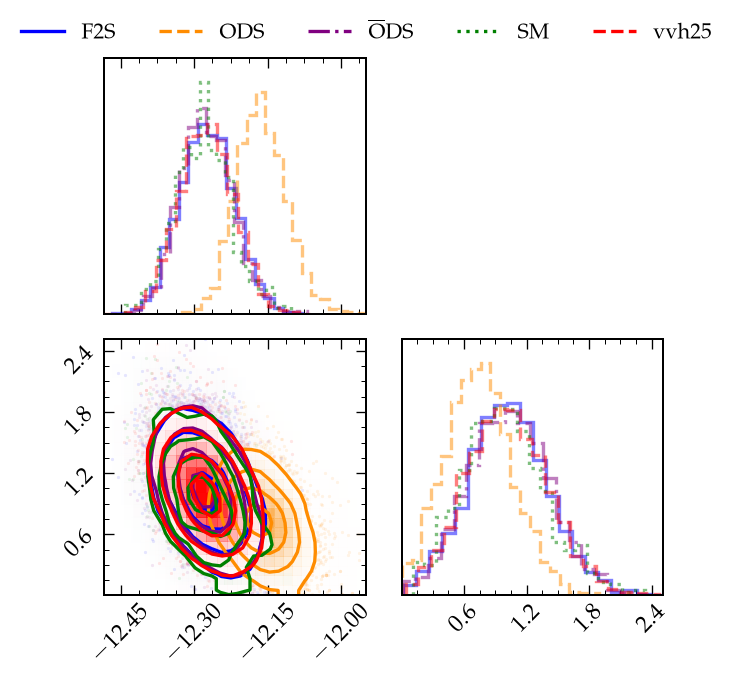

In [110]:
import matplotlib.lines as mlines

figure = corner.corner(irn_samples_flow,
                       hist_kwargs={"density": True, "alpha": 0.5, "color": "blue",
                                    "linestyle": "solid", "lw": 2},
                       color='blue',
                       show_titles=False,
                       smooth = True,
                       label = "F2S")

corner.corner(irn_samples_ds,
              hist_kwargs={"density": True, "alpha": 0.5, "color": "darkorange",
                           "linestyle": "dashed", "lw": 2},
              color='darkorange',
              fig=figure,
              show_titles=False,
              labelpad = 0.1,
              smooth = True,
              label = "O-DS")


corner.corner(pd.DataFrame(samples_ds_outliers_rem),
              hist_kwargs={"density": True, "alpha": 0.5, "color": "purple",
                           "linestyle": "dashdot", "lw": 2},
              color='purple',
              fig=figure,
              show_titles=False,
              labelpad = 0.1,
              smooth = True,
              label = r"$\mathrm{\overline{O}-DS}$")

corner.corner(pd.DataFrame(smsamples),
            hist_kwargs={"density": True, "alpha": 0.5, "color": "green",
                           "linestyle": "dotted", "lw": 2},
              color='green',
              fig=figure,
              show_titles=False,
              labelpad = 0.1,
              smooth = True,
              label = "SM")

corner.corner(pd.DataFrame(samples_vanilla),
            hist_kwargs={"density": True, "alpha": 0.5, "color": "red",
                           "linestyle": "dashed", "lw": 2},
              color='red',
              fig=figure,
              show_titles=False,
              labelpad = 0.1,
              smooth = True,
              label = "SM")
              
              
legend_handles = [mlines.Line2D([], [], color='blue', linestyle='solid',    linewidth=2, label='F2S'),
    mlines.Line2D([], [], color='darkorange', linestyle='dashed',   linewidth=2, label='ODS'),
    mlines.Line2D([], [], color='purple', linestyle='dashdot',  linewidth=2, label=r'$\mathrm{\overline{O}DS}$'),
     mlines.Line2D([], [], color='green', linestyle='dotted',  linewidth=2, label='SM',),
    mlines.Line2D([], [], color='red', linestyle='dashed',  linewidth=2, label='vvh25')]

figure.legend(handles=legend_handles, 
              loc='upper center',
              ncol = 5,
              bbox_to_anchor = (0.5, 1.05))

#figure.suptitle(psr.name, fontsize = 20, y = 1.02)
plt.tight_layout()
plt.show()

# Testing the updated formalism

$$
\renewcommand{\bxi}{\boldsymbol{\xi}}
\renewcommand{\etab}{\boldsymbol{\eta}}
\newcommand{\ahat}{\mathbf{\hat a}}

\begin{aligned}
p(\bxi, \etab)
&\propto
\prod_{p=1}^{N_p}
\left[
\frac{
f_{\psi,p}(\mathbf y_p(\bxi, \etab)\mid \boldsymbol{\eta}_{0,p}, \boldsymbol{\delta t}_p)
|\det \mathbf L_{0,p}|^{-1}
}{
\mathcal N(\mathbf a_p(\bxi, \etab)\mid \hat{\mathbf a}_{0,p}, \boldsymbol\Sigma_{0,p}; \boldsymbol{\eta}_{0,p})
}
\right]
\frac{|\det \mathbf L_{\mathrm{CURN}}|}
{\sqrt{\det(2\pi\boldsymbol{\varphi}(\etab))}}
\\
&\quad\times
\exp\Big[
-\tfrac12
(\ahat_{\mathrm{CURN}}+\mathbf L_{\mathrm{CURN}}\bxi)^\top
\boldsymbol\Sigma^{-1}
(\ahat_{\mathrm{CURN}}+\mathbf L_{\mathrm{CURN}}\bxi)
+
(\ahat_{\mathrm{CURN}}+\mathbf L_d\bxi)^\top
\boldsymbol\Sigma_0^{-1}
\ahat_0
\Big]
\,p(\etab),
\\
\mathbf y_p(\bxi,\etab)
&=
\mathfrak L_{p,(y)}\!\bigl(\mathbf a_p(\bxi,\etab)\bigr)
=
\mathfrak L_{p,(y)}
\bigl[\mathfrak D^{-1}_{(a)}(\bxi,\etab)\bigr]_p.
\end{aligned}
$$

In [112]:
def log_fourier_joint_single_flow_corrected_v2(rho, xi, bf, phi_func, TtNTf,
                                             logL_flow_list, ahat_0, L_0,
                                             log_gauss_normconst):

    phi_inv, logdet_phi = phi_func(rho)
    Sigma_inv = TtNTf + phi_inv
    L_sinv = jnp.linalg.cholesky(Sigma_inv)

    ahat = jsp.linalg.cho_solve((L_sinv, True), bf)
    a = ahat + jsp.linalg.solve_triangular(L_sinv.T, xi, lower=False)

    quad_a   = a @ Sigma_inv @ a
    linear_a = bf @ a
    log_det_L = -jnp.sum(jnp.log(jnp.diag(L_sinv)))

    logL = -0.5 * quad_a + linear_a + log_det_L - 0.5 * logdet_phi

    a_diff = a - ahat_0
    y = jsp.linalg.solve_triangular(L_0, a_diff, lower=True)
    numpyro.deterministic("y", y)

    log_p_flow = logL_flow_list[0](y)
    log_p_gauss = -0.5 * jnp.sum(y ** 2) + log_gauss_normconst

    log_flow_diff = log_p_flow - log_p_gauss
    numpyro.factor("flowCorrection", log_flow_diff)
    numpyro.deterministic("flow_normal_ratio", jnp.exp(log_flow_diff))

    return logL, a

In [ ]:


def run_step2_SPNA_flow_corrected(summaries, psrs, phi_func, priordict,
                                   components=None, Tspan=None,
                                   n_warmup=1000, n_samples=3000, rng_key=0):

    rng_key = jax.random.key(rng_key)

    for s in summaries:
        if not s.is_ready_for_step2:
            raise ValueError(f"{s.name} is not ready for step 2.")

    if components is None:
        components = summaries[0].n_coeff // 2
    if Tspan is None:
        Tspan = signals.getspan(psrs)

    f, df, _ = signals.fourierbasis(psrs[0], components, T=Tspan)

    n = len(psrs)
    phi_func_list = phi_func if isinstance(phi_func, list) else [phi_func] * n

    all_samples = {}
    for i, s in enumerate(summaries):

        bf = s.bf
        TtNTf = s.TtNTf
        L_0 = s.L0r
        logL_flow_list = [lambda y, s=s: s.flow.log_prob(y) - jnp.sum(jnp.log(jnp.diag(s.L0r)))]
        log_const0 = s.log_const0
        xi_shape = (2*components,)
        
        log_gauss_normconst = (-0.5 * float(s.L_f.shape[0]) * jnp.log(2 * jnp.pi)
                               - jnp.sum(jnp.log(jnp.diag(s.L_f))))
        
        psr_params = {}
        rn_params = []
        for eta_key, eta_val in s.eta0.items():
            size = len(eta_val) if hasattr(eta_val, '__len__') else 1
            rn_name = (f"{s.name}_red_noise_{eta_key}({size})" if size > 1
                       else f"{s.name}_red_noise_{eta_key}")
            psr_params[eta_key] = rn_name
            rn_params.append((rn_name, size, _lookup_prior(rn_name, priordict)))

        phi_func_i = partial(phi_func_list[i], psr_params_list=[psr_params], f=f, df=df)


        def model(rn_params=rn_params, phi_func_i=phi_func_i,
                  bf=bf, TtNTf=TtNTf, log_const0=log_const0,
                  logL_flow_list=logL_flow_list, ahat_0=ahat0r, L_0=L_0,
                  xi_shape=xi_shape,
                  log_gauss_normconst=log_gauss_normconst):

            rho = {}
            for rn_name, size, rng in rn_params:
                d = dist.Uniform(*rng)
                rho[rn_name] = numpyro.sample(rn_name, d.expand([size]) if size > 1 else d)

            xi = numpyro.sample("xi", dist.Normal(jnp.zeros(xi_shape), jnp.ones(xi_shape)))
             
            logL, a = log_fourier_joint_single_flow_corrected_v2(
                rho=rho, xi=xi, bf=bf, phi_func=phi_func_i, TtNTf=TtNTf,
                logL_flow_list=logL_flow_list, ahat_0=ahat0r, L_0=L_0,
                log_gauss_normconst=log_gauss_normconst)

            numpyro.deterministic("a", a)
            numpyro.factor("logL", logL + log_const0 + 0.5 * jnp.sum(xi ** 2))
            

        init_params = {rn_name: jnp.asarray(s.eta0[eta_key])
                       for eta_key, rn_name in psr_params.items()}
        init_params["xi"] = jnp.zeros(xi_shape)

        print(f"[{i+1}/{len(summaries)}] Running step 2 SPNA flow-corrected for {s.name}")
        rng_key_i = jax.random.fold_in(rng_key, i)
        kernel  = infer.NUTS(model, init_strategy=infer.init_to_value(values=init_params))
        sampler = infer.MCMC(kernel, num_warmup=n_warmup, num_samples=n_samples, progress_bar=True)
        sampler.run(rng_key_i)
        all_samples[s.name] = sampler.get_samples()

    return all_samples

In [143]:
flow_psr_v2 = copy.deepcopy(flow_psr)

In [144]:
flow_psr_v2.__dict__

{'name': 'J1643-1224',
 'psl': <discovery.likelihood.PulsarLikelihood at 0x210a37be710>,
 'eta0': {'log10_A': -12.0, 'gamma': 3.0},
 'phi0_inv': Array([[4.81637590e+08, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 4.81637590e+08, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 3.85310072e+09, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         1.17466592e+13, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 1.30042149e+13, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 1.30042149e+13]], dtype=float64),
 'logdet_phi0': Array(-1647.51156814, dtype=float64),
 'ahat0r': Array([-1.46128754e-05,  4.95420951e-06, 

In [166]:
# use this as our new decentering quantities
flow_psr_v2.ahat0r = summaries_vanilla[0].ahat0
flow_psr_v2.L0r = summaries_vanilla[0].L0

In [182]:
# since the decentering quantities are changed, we also have to redo the normalizing flow fit
flow_psr_v2.flow = None
flow_psr_v2.samples = sampler.get_samples() # get the samples from the outlier run
compute_flow_summaries([flow_psr_v2], 0, 
                       n_flow_samples=int(1e6), 
                       learning_rate = 1e-3,
                       batch_size = 1024,
                       max_epochs = 5000,
                       flow_architecture=affine_flow_architecture) # defaults to the MAF architecture

[1/1]: Running flow step for pulsar J1643-1224


  2%|▏         | 101/5000 [00:00<00:45, 106.59it/s, train=83.9, val=86.3 (Max patience reached)]


Finished flow-fit to pulsar J1643-1224.


In [183]:
# the above populates the flow_psr_v2 with flow properties which we now have to replace 
# with the vanilla objects (which we have access to from our previous run)
flow_psr_v2.ahat_f = summaries_vanilla[0].ahat0
flow_psr_v2.L_f = summaries_vanilla[0].L0
flow_psr_v2.Sigma_f = summaries_vanilla[0].Sigma0
flow_psr_v2.bf = summaries_vanilla[0].b0
flow_psr_v2.TtNTf = summaries_vanilla[0].TtNT

In [184]:
samples_updated = run_step2_SPNA_flow_corrected([flow_psr_v2],[psr], ds.partial(phi_SPNA, powerlaw= ds.powerlaw), priordict_standard,
                    n_warmup=1024, n_samples=4096)

[1/1] Running step 2 SPNA flow-corrected for J1643-1224


sample: 100%|██████████| 5120/5120 [00:20<00:00, 247.95it/s, 7 steps of size 4.72e-01. acc. prob=0.86]


In [185]:
samples_updated = samples_updated[psr.name]
samples_updated = pd.DataFrame({labels[i]: samples_updated[k] for i, k in enumerate(labels_init)})

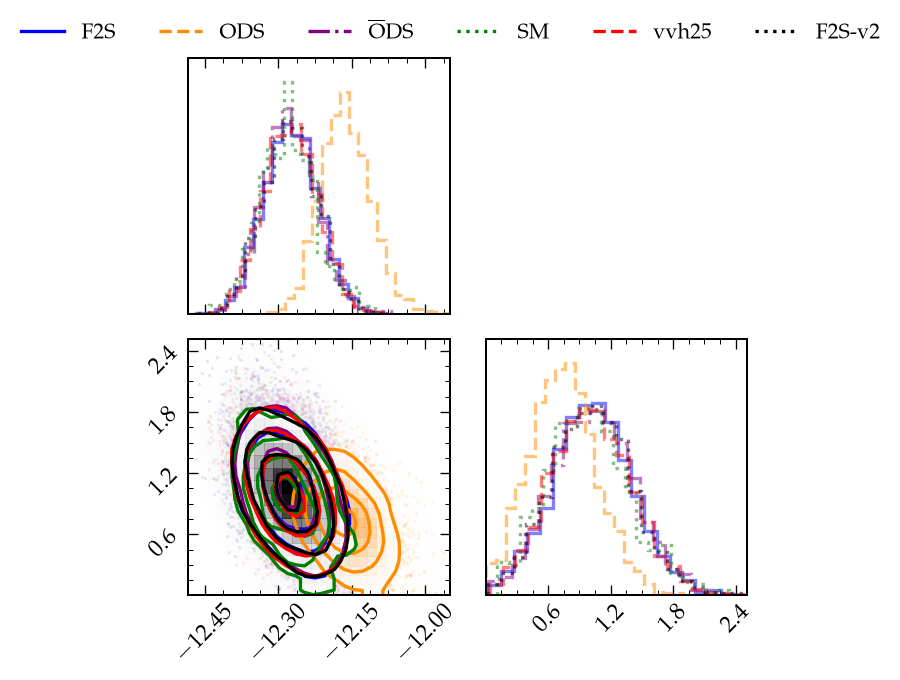

In [186]:
import matplotlib.lines as mlines

figure = corner.corner(irn_samples_flow,
                       hist_kwargs={"density": True, "alpha": 0.5, "color": "blue",
                                    "linestyle": "solid", "lw": 2},
                       color='blue',
                       show_titles=False,
                       smooth = True,
                       label = "F2S")

corner.corner(irn_samples_ds,
              hist_kwargs={"density": True, "alpha": 0.5, "color": "darkorange",
                           "linestyle": "dashed", "lw": 2},
              color='darkorange',
              fig=figure,
              show_titles=False,
              labelpad = 0.1,
              smooth = True,
              label = "O-DS")


corner.corner(pd.DataFrame(samples_ds_outliers_rem),
              hist_kwargs={"density": True, "alpha": 0.5, "color": "purple",
                           "linestyle": "dashdot", "lw": 2},
              color='purple',
              fig=figure,
              show_titles=False,
              labelpad = 0.1,
              smooth = True,
              label = r"$\mathrm{\overline{O}-DS}$")

corner.corner(pd.DataFrame(smsamples),
            hist_kwargs={"density": True, "alpha": 0.5, "color": "green",
                           "linestyle": "dotted", "lw": 2},
              color='green',
              fig=figure,
              show_titles=False,
              labelpad = 0.1,
              smooth = True,
              label = "SM")

corner.corner(pd.DataFrame(samples_vanilla),
            hist_kwargs={"density": True, "alpha": 0.5, "color": "red",
                           "linestyle": "dashed", "lw": 2},
              color='red',
              fig=figure,
              show_titles=False,
              labelpad = 0.1,
              smooth = True,
              label = "SM")

corner.corner(pd.DataFrame(samples_updated),
            hist_kwargs={"density": True, "alpha": 0.5, "color": "black",
                           "linestyle": "dotted", "lw": 2},
              color='black',
              fig=figure,
              show_titles=False,
              labelpad = 0.1,
              smooth = True,
              label = "F2S-v2")
              
              
              
legend_handles = [mlines.Line2D([], [], color='blue', linestyle='solid',    linewidth=2, label='F2S'),
    mlines.Line2D([], [], color='darkorange', linestyle='dashed',   linewidth=2, label='ODS'),
    mlines.Line2D([], [], color='purple', linestyle='dashdot',  linewidth=2, label=r'$\mathrm{\overline{O}DS}$'),
     mlines.Line2D([], [], color='green', linestyle='dotted',  linewidth=2, label='SM',),
    mlines.Line2D([], [], color='red', linestyle='dashed',  linewidth=2, label='vvh25'),
    mlines.Line2D([], [], color='black', linestyle='dotted',  linewidth=2, label='F2S-v2'),
    ]

figure.legend(handles=legend_handles, 
              loc='upper center',
              ncol = 6,
              bbox_to_anchor = (0.5, 1.05))

#figure.suptitle(psr.name, fontsize = 20, y = 1.02)
plt.tight_layout()
plt.show()